centrality
- Degree
- Betweenness
- Pagerank
- CI

## MultiStage mind_wrapper

### Stage 1: Preprocess


### Stage 2: Dismantling

In [1]:
import igraph as ig
import torch
from copy import deepcopy
from typing import Callable,Dict
import numpy as np
import os
from task_encoder import TaskEncoder
from networks.dismantle import load_sac_dismantler,load_sac_dismantler_with_film, DQNPolicy, load_dqn_dismantler
import utils
import importlib
import baseline
import evaluate
importlib.reload(utils)
importlib.reload(baseline)
importlib.reload(evaluate)
from baseline import ensure_attribute
from evaluate import mind_dismantling
  
# def mind_warpper(graph:ig.Graph,ckpt_pth=None,gnn='mind',**kwargs):
#     '''
#     same return with preprocess
#     removals: complete solution
#     removed_sizes: cumulative removed number at each step, start from 0
#     lcc_sizes: lcc size at each step, len(lcc_sizes) = len(removed_sizes)
#     '''
#     graph = deepcopy(graph)
#     ensure_attribute(graph)
    
#     # defalut value when no args.config
#     # device: str='cuda:0'
#     device = torch.device('cpu')
#     F = 16; H = 4; K = 6
#     gnn = 'mind'

#     from utils.validate import validate_one_graph
    
#     if 'sac' in ckpt_pth:
#         policy, _, _, _, _ = load_sac_dismantler(F, H, K, gnn, device, ckpt_pth)
#         auc, robustness, _, removals = validate_one_graph(graph,policy=policy,log_removals=True)
#     else:
#         qf, _ = load_dqn_dismantler(F, H, K, gnn, device, ckpt_pth)
#         policy = DQNPolicy(qf)
#         auc, robustness, _, removals = validate_one_graph(graph,policy=policy,log_removals=True)
        
    
#     return auc, robustness, removals


from utils.common import load_g
G = load_g("graphs/simple/simple_100.pkl",name="test")
test_auc, test_robustness, test_removals = mind_dismantling(
    G,
    ckpt_pth = 'saved/mind/mind.ckpt',
    # ckpt_pth = 'saved/gcn/sac_20260309_111018/13999.ckpt',
    # ckpt_pth = 'saved/graphsage/dqn_20260316_183559/11999.ckpt',
    # ckpt_pth= 'saved/hgnn_v4/sac_graph_task_frozen_film_20260130_191042/13999.ckpt',
    step_ratio = 0
)


import baseline
import importlib
importlib.reload(baseline)
from baseline import evaluate_sol
test_auc, test_robustness, lcc_sizes, removed_sizes = evaluate_sol(G,test_removals)
print(test_auc,test_robustness)
print(len(lcc_sizes),len(removed_sizes))



d:\Anaconda3\envs\torch_py38\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded graph test
Graph: test, AUC=0.469233, Robustness=0.464500, Steps=85
0.46923333333333334 0.4645
86 86


method ABCDE: AUC=0.037463, Robustness=0.037378, runtime=6.894198


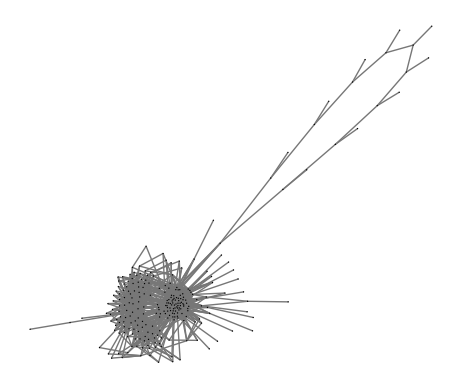

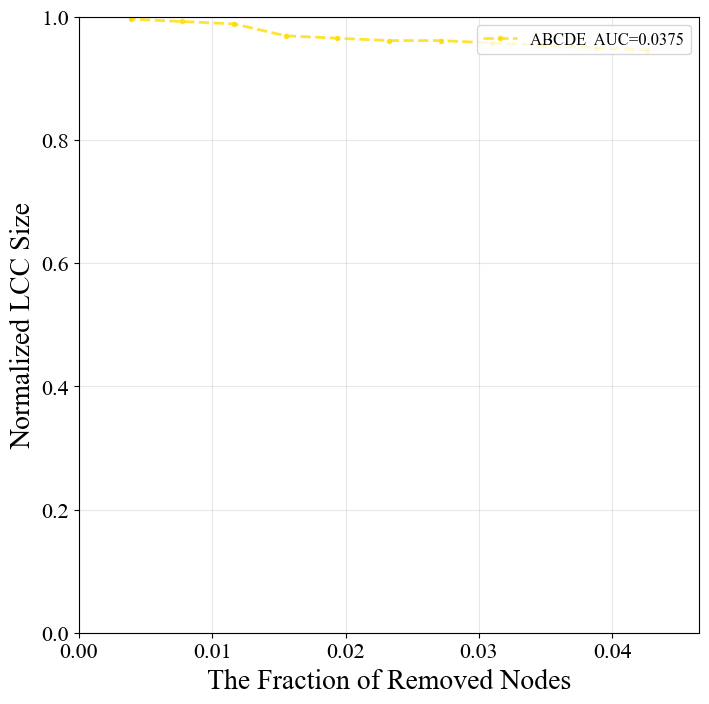

In [8]:
import igraph as ig
import os
import importlib
import baseline
import visualize_dismantling
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils import graph_models
importlib.reload(graph_models)
import time
from utils.plot import plot_graph
from utils.common import load_g
from utils.graph_models import *
from baseline import baseline_dismantling,METHODS,_get_removals_path

# g = SBM(80,p_in=0.15,p_out=0.0075,num_blocks=2)
# g = SBM(96,p_in=0.12,p_out=0.01,num_blocks=3)
# g = SBM(200, p_in=0.1,p_out=0.005, num_blocks=2)
# g = SBM(4000, p_in=0.01,p_out=0.0005, num_blocks=2)
# g = WS(200,k=4,p=0.1)
# g = BA(200, m=4)
# g = BA(5000, m=4)
# g = ER(200, p=0.1)
# g = DCSBM(120,p_in=0.3,p_out=0.01,num_blocks=5)
# g = ring_community(120,p_in=0.2,num_communities=4)
# g = star_community(120,p_in=0.15,num_communities=5)
# g = barbell(120,p_in=0.1,path_len=3,type="ER")
# g['name'] = 'test'


# g = WS(5000,k=4,p=0.3)
# g = ER(5000,p=0.001)
# g = BA(5000,m=4)
# p_in = 0.01
# p_out = p_in/30
# g = SBM(1000, p_in=p_in,p_out=p_out, num_blocks=2)
# g['name'] = 'test'
# with open(f'graphs/test/SBM_n_1000_pi_{p_in}_num_blocks_2.pkl','wb') as f:
#     pickle.dump(g,f)

# g_name = 'graphs/test/BA_n_500_m_4.pkl'
# g_name = 'graphs/test/BA_n_1000_m_4.pkl'
# g_name = 'graphs/test/BA_n_5000_m_4.pkl'
# g_name = 'graphs/test/ER_n_500_p_0.01.pkl'
# g_name = 'graphs/test/ER_n_1000_p_0.005.pkl'
# g_name = 'graphs/test/ER_n_5000_p_0.001.pkl'
# g_name = 'graphs/test/WS_n_500_k_4_p_0.3.pkl'
# g_name = 'graphs/test/WS_n_1000_k_4_p_0.3.pkl'
# g_name = 'graphs/test/WS_n_5000_k_4_p_0.3.pkl'
# g_name = 'graphs/test/SBM_n_500_pi_0.02_num_blocks_2.pkl'
# g_name = 'graphs/test/SBM_n_1000_pi_0.01_num_blocks_2.pkl'

# g_name = 'graphs/real/bio/foodweb-baywet.pkl'
# g_name = 'graphs/real/bio/foodweb-baydry.pkl'
# g_name = 'graphs/real/bio/maayan-foodweb.pkl'
# g_name = 'graphs/real/bio/dimacs10-celegansneural.pkl'
# g_name = 'graphs/real/bio/arenas-meta.pkl'
# g_name = 'graphs/real/bio/maayan-Stelzl.pkl'
# g_name = 'graphs/real/bio/moreno_propro.pkl'
# g_name = 'graphs/real/bio/maayan-figeys.pkl'
# g_name = 'graphs/real/bio/maayan-vidal.pkl'
# g_name = 'graphs/real/bio/ppi.pkl'
# g_name = 'graphs/real/social/librec-filmtrust-trust.pkl'
# g_name = 'graphs/real/social/opsahl-ucsocial.pkl'
# g_name = 'graphs/real/social/ego-facebook.pkl'
# g_name = 'graphs/real/social/librec-ciaodvd-trust.pkl'
# g_name = 'graphs/real/social/soc-Epinions1.pkl'
g_name = 'graphs/real/information/econ-wm1.pkl'
# g_name = 'graphs/real/information/dimacs10-polblogs.pkl'
# g_name = 'graphs/real/information/citeseer.pkl'
# g_name = 'graphs/real/information/dblp-cite.pkl'
# g_name = 'graphs/real/information/subelj_jdk_jdk.pkl'
# g_name = 'graphs/real/information/linux.pkl'

# g_name = 'graphs/real/tech/eu-powergrid.pkl'
# g_name = 'graphs/real/tech/openflights-airport.pkl'

g = load_g(g_name,name=os.path.basename(g_name).split('.')[0])
g = g.subgraph(max(g.connected_components(), key=len)) 
plot_graph(g)

all_results = {}
compare_mind_ckpts = [
                    # 'saved/mind/mind.ckpt',
                    # 'saved/rfgnn/sac_teacher_betweenness_20260310_083133/24999.ckpt',
                    
                    # 'saved/gin/sac_20260328_001514/19999.ckpt',
                    # 'saved/rfgnn/sac_teacher_20260320_000339/10999.ckpt',
                    # 'saved/rfgnn/sac_teacher_betweenness_20260310_083133/15999.ckpt',

                    # 'saved/graphsage/dqn_teacher_20260324_115255/14999.ckpt',
                    # 'saved/gcn/dqn_20260317_014845/14999.ckpt', #GCN DQN 
                    # 'saved/gcn/dqn_teacher_20260322_162759/19999.ckpt', #GCN DQN None
                    # 'saved/gcn/dqn_teacher_20260322_190135/17999.ckpt', #GCN DQN PRE
                    # 'saved/gcn/dqn_teacher_20260322_202521/14999.ckpt', #GCN DQN PRE+RS*0.1(训练时间不足..) 
                    # 'saved/gcn/sac_20260316_144026/19999.ckpt', #GCN SAC
                    # 'saved/graphsage/dqn_20260316_183559/24999.ckpt', #GraphSAGE DQN
                    # 'saved/graphsage/dqn_teacher_20260316_194430/23999.ckpt', #GraphSAGE DQN PRE
                    # 'saved/graphsage/sac_20260316_144118/16999.ckpt', #GraphSAGE SAC
                    # 'saved/graphsage/sac_teacher_20260322_213146/13999.ckpt', #GraphSAGE SAC BC+RS

                    # 'saved/gcn/dqn_teacher_20260326_003122/18999.ckpt',
                    # 'saved/gcn/dqn_teacher_20260326_073910/11999.ckpt',
                    # 'saved/graphsage/sac_teacher_20260324_224237/33999.ckpt',
                    # 'saved/graphsage/sac_teacher_20260325_103432/14999.ckpt',
                    # 'saved/gcn/sac_teacher_20260325_153924/10999.ckpt',
                    # 'saved/gcn/sac_teacher_20260326_134020/4999.ckpt',
                    # 'saved/gcn/sac_20260326_134151/9999.ckpt',
                   
                    # 'saved/gcn/sac_teacher_20260325_153924/3999.ckpt',
                    # 'saved/graphsage/sac_teacher_20260325_103432/2999.ckpt',
                    
                    # 'saved/rfgnn/sac_teacher_20260320_000339/10999.ckpt',
                    # 'saved/hgnn_v2/finetune_prior_20260120_200915/19999.ckpt',
                    # 'saved/hgnn_v4/sac_20260222_224028/24999.ckpt',
                    # 'saved/hgnn_v4/sac_20260222_224028/20999.ckpt',
                    # 'saved/hgnn_v4/sac_20260222_224028/23999.ckpt',

                    # 'saved/graphsage/dqn_20260410_134550/17999.ckpt',
                    # 'saved/graphsage/sac_20260407_125653/24999.ckpt',
                    # 'saved/graphsage/dqn_teacher_20260410_183208/23999.ckpt',
                    # 'saved/graphsage/sac_teacher_20260406_215041/19999.ckpt',
                    # 'saved/graphsage/sac_teacher_20260414_095713/21999.ckpt',
                    # 'saved/graphsage/sac_teacher_20260406_215041/bc.ckpt',
                    # 'saved/graphsage/sac_teacher_20260406_215041/12999.ckpt',
                    # 'saved/graphsage/sac_teacher_20260406_215041/20999.ckpt',

                    # 'saved/rfgnn/sac_teacher_20260420_143615/bc.ckpt',
                    # 'saved/rfgnn/sac_teacher_20260420_143615/9999.ckpt',
                    # 'saved/rfgnn/sac_teacher_20260421_065917/19999.ckpt',
                    # 'saved/domain_adapt_20260422_141118/5000.ckpt'

                    # 'saved/gat/sac_20260320_113356/7999.ckpt',
                    # 'saved/gat/sac_teacher_20260324_190918/6999.ckpt'
                    ]

# method_names = ["D&E-SAC-W/O RS",'D&E-SAC-RS/KL','D&E-SAC-RS/2core']
# method_names = ['All','W/O Differential Flow','W/O Attention','W/O Residual Connection','W/O Identity Mapping']
for idx, ckpt_pth in enumerate(compare_mind_ckpts):
    print(ckpt_pth)
    time_start = time.time()
    step_ratio = 0.0
    _, _, removals  = mind_dismantling(g,step_ratio=step_ratio,ckpt_pth=ckpt_pth)
    # method_name = ckpt_pth.split("/",1)[-1]
    print(f"time = {time.time()-time_start}")
    
    method_name = str(idx)+ '-' + os.path.basename(ckpt_pth).replace('.ckpt', '')
    cache_path = _get_removals_path(g, method_name, threshold=0.1)
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with open(cache_path, "w", encoding="utf-8") as f:
        f.write("\n".join(str(int(node_id)) for node_id in removals))
        if removals:
            f.write("\n")

    auc, r, lcc_sizes, removed_sizes = evaluate_sol(g,removals,threshold=0.1)
    # all_results[method_names[idx]] = {
    all_results[method_name] = {
        'removals': removals,
        'auc': auc,
        'robustness': r,
        'lcc_sizes': lcc_sizes,
        'removed_sizes': removed_sizes,
        # 'lambda_list': lambda_list,
    }

from baseline import baseline_dismantling,METHODS
methods = {
    # "Spectral":METHODS['Spectral'],
    # "AD":METHODS['Degree'],
    # "AB":METHODS['Betweenness'],
    # "SD":METHODS['DegreeNA'],
    # "SB":METHODS['BetweennessNA'],
    "ABCDE":METHODS["ABCDE"],
    # "CI": METHODS['CI'],
    # "CoreHD":METHODS['CoreHD'],
    # "PageRank":METHODS['PageRank'],
    # # "FINDER":METHODS['FINDER'],
    # "GDM":METHODS['GDM'],
    # "CoreGDM":METHODS['CoreGDM'],
    # "DomiRank":METHODS['DomiRank'],
    # "NIRM":METHODS['NIRM'],
    # "GND":METHODS['GND'],
    # "TSAM":METHODS['TSAM'],
    # "MinSum":METHODS["MinSum"]
}
# baseline_results = baseline_dismantling(g,methods,visualize=False,threshold=0.1,save_removals=True)
baseline_results = baseline_dismantling(g,methods,visualize=False,threshold=0.1)
all_results.update(baseline_results)

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g,all_results)

### compare mind_wrapper models

graphs/real/bio/foodweb-baywet.pkl 128
   Num_nodes  Num_edges  AvgDegree  Diam  AvgShortPath  Clustering Coffe  \
0      128.0     2075.0  32.421875   3.0      1.776329          0.334622   

          r         Q  
0 -0.111663  0.172047  
Calculating best minimal value for power law fit


Fitting xmin: 100%|██████████| 48/48 [00:00<00:00, 2901.00it/s]

saved/mind/mind.ckpt
Loaded graph graphs/real/bio/foodweb-baywet.pkl


Graph: graphs/real/bio/foodweb-baywet.pkl, AUC=0.396637, Robustness=0.393127, Steps=90
saved/rfgnn/sac_teacher_betweenness_20260310_083133/24999.ckpt
Loaded graph graphs/real/bio/foodweb-baywet.pkl
Graph: graphs/real/bio/foodweb-baywet.pkl, AUC=0.357198, Robustness=0.353577, Steps=74
saved/graphsage/dqn_teacher_20260324_115255/14999.ckpt
Loaded graph graphs/real/bio/foodweb-baywet.pkl
Graph: graphs/real/bio/foodweb-baywet.pkl, AUC=0.487823, Robustness=0.484314, Steps=116
saved/gcn/dqn_20260317_014845/14999.ckpt
Loaded graph graphs/real/bio/foodweb-baywet.pkl
Graph: graphs/real/bio/foodweb-baywet.pkl, AUC=0.487823, Robustness=0.484314, Steps=116
saved/gcn/dqn_teacher_20260322_162759/19999.ckpt
Loaded graph graphs/real/bio/foodweb-baywet.pkl
Graph: graphs/real/bio/foodweb-baywet.pkl, AUC=0.485565, Robustness=0.482056, Steps=114
saved/gcn/dqn_teacher_20260322_190135/17999.ckpt
Loaded graph graphs/real/bio/foodweb-baywet.pkl
Graph: graphs/real/bio/foodweb-baywet.pkl, AUC=0.487823, Robustne

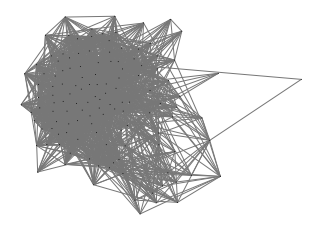

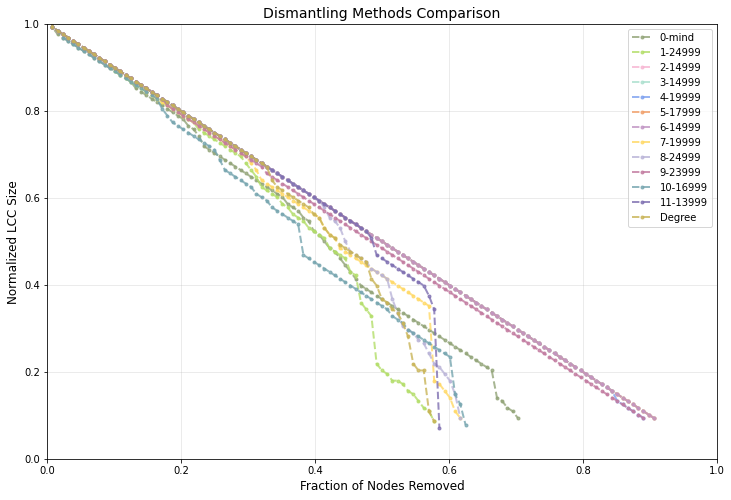

In [ ]:
import matplotlib.pyplot as plt
import os
import importlib
import utils
import visualize_dismantling
import baseline
importlib.reload(utils)
importlib.reload(visualize_dismantling)
importlib.reload(baseline)
from utils.common import load_g
from utils.graph_models import statistics
from utils.plot import plot_graph
from utils.structural_diversity_analysis import analyze_powerlaw
# g_name = 'graphs/real/bio/.pkl'


# g_name = 'graphs/real/bio/foodweb-baywet.pkl'
# g_name = 'graphs/real/bio/foodweb-baydry.pkl'
# g_name = 'graphs/real/bio/maayan-foodweb.pkl'
# g_name = 'graphs/real/bio/dimacs10-celegansneural.pkl'
# g_name = 'graphs/real/bio/arenas-meta.pkl'
# g_name = 'graphs/real/bio/maayan-Stelzl.pkl'
# g_name = 'graphs/real/bio/moreno_propro.pkl'
# g_name = 'graphs/real/bio/maayan-figeys.pkl'
# g_name = 'graphs/real/bio/maayan-vidal.pkl'

# g_name = 'graphs/real/social/librec-filmtrust-trust.pkl'
# g_name = 'graphs/real/social/opsahl-ucsocial.pkl'
# g_name = 'graphs/real/social/petster-hamster.pkl'
# g_name = 'graphs/real/social/librec-ciaodvd-trust.pkl'
# g_name = 'graphs/real/social/advogato.pkl'
# g_name = 'graphs/real/social/pajek-erdos.pkl'
# g_name = 'graphs/real/social/ego-twitter.pkl'
# g_name = 'graphs/real/social/munmun_digg_reply_LCC.pkl'
g_name = 'graphs/real/social/slashdot-threads.pkl'

# g_name = 'graphs/real/information/econ-wm1.pkl'
# g_name = 'graphs/real/information/dimacs10-polblogs.pkl'
# g_name = 'graphs/real/information/web-EPA.pkl'
# g_name = 'graphs/real/information/subelj_jung-j_jung-j.pkl'
# g_name = 'graphs/real/information/subelj_jdk_jdk.pkl'
# g_name = 'graphs/real/information/p2p-Gnutella06.pkl'
# g_name = 'graphs/real/information/dblp-cite.pkl'

# g_name = 'graphs/real/tech/london_transport_multiplex_aggr.pkl'
# g_name = 'graphs/real/tech/eu-powergrid.pkl'
# g_name = 'graphs/real/tech/opsahl-openflights.pkl'
# g_name = 'graphs/real/tech/gridkit-eupowergrid.pkl'
# g_name = 'graphs/real/tech/gridkit-north_america.pkl'
# g_name = 'graphs/real/tech/internet-topology.pkl'

# g_name = 'graphs/gen/citeseer.pkl'
# g_name = 'graphs/gen/cora.pkl'
# g_name = 'graphs/gen/ego-facebook.pkl'

g = load_g(g_name,name=g_name)
print(g['name'],g.vcount())

# g_lcc = g.subgraph(max(g.connected_components(), key=len))
g_lcc = g.connected_components().giant()
plot_graph(g_lcc)
print(statistics(g_lcc))
analyze_powerlaw(g_lcc)
exit()

all_results = {}
# compare_mind_ckpts = [
#                     'saved/mind/mind.ckpt',
#                     # 'saved/rfgnn/sac_teacher_20260129_163549/18999.ckpt',
#                     # 'saved/hgnn_v4/sac_20260216_102427/53999.ckpt',
#                     # 'saved/hgnn_v4/sac_teacher_betweenness_20260201_151201/40999.ckpt',
#                     # 'saved/hgnn_v5/sac_teacher_betweenness_20260309_210139/23999.ckpt',
#                     'saved/rfgnn/sac_teacher_betweenness_20260310_083133/24999.ckpt'
#                     ]
compare_mind_ckpts = [
                    'saved/mind/mind.ckpt',
                    'saved/rfgnn/sac_teacher_betweenness_20260310_083133/24999.ckpt',
                    'saved/graphsage/dqn_teacher_20260324_115255/14999.ckpt',
                    'saved/gcn/dqn_20260317_014845/14999.ckpt', #GCN DQN 
                    'saved/gcn/dqn_teacher_20260322_162759/19999.ckpt', #GCN DQN None
                    'saved/gcn/dqn_teacher_20260322_190135/17999.ckpt', #GCN DQN PRE
                    'saved/gcn/dqn_teacher_20260322_202521/14999.ckpt', #GCN DQN PRE+RS*0.1(训练时间不足..) 
                    'saved/gcn/sac_20260316_144026/19999.ckpt', #GCN SAC
                    'saved/graphsage/dqn_20260316_183559/24999.ckpt', #GraphSAGE DQN
                    'saved/graphsage/dqn_teacher_20260316_194430/23999.ckpt', #GraphSAGE DQN PRE
                    'saved/graphsage/sac_20260316_144118/16999.ckpt', #GraphSAGE SAC
                    'saved/graphsage/sac_teacher_20260322_213146/13999.ckpt', #GraphSAGE SAC BC+RS
                    # 'saved/gat/sac_20260320_113356/7999.ckpt'
                    ]

for idx, ckpt_pth in enumerate(compare_mind_ckpts):
    print(ckpt_pth)
    gnn = ckpt_pth.split("/")[1]
    _, _, removals  = mind_dismantling(g_lcc,step_ratio=0.0,ckpt_pth=ckpt_pth)
    method_name = str(idx)+ '-' + os.path.basename(ckpt_pth).replace('.ckpt', '')
    auc, r, lcc_sizes, removed_sizes = evaluate_sol(g_lcc,removals,threshold=0.1)
    all_results[method_name] = {
        'removals': removals,
        'auc': auc,
        'robustness': r,
        'lcc_sizes': lcc_sizes,
        'removed_sizes': removed_sizes,
        # 'lambda_list': lambda_list,
    }

from baseline import baseline_dismantling,METHODS
methods = {
    # "Spectral":METHODS['Spectral'],
    # "Random":METHODS['Random'],
    "Degree":METHODS['Degree'],
    # "Betweenness":METHODS['Betweenness'],
    # "CI": METHODS['CI'],
    # "PageRank":METHODS['PageRank'],
    # "CoreHD":METHODS['CoreHD'],
    # "MinSum":METHODS['MinSum'],
    # 'FINDER':METHODS['FINDER']
}
baseline_results = baseline_dismantling(g_lcc,methods,threshold=0.1,visualize=False)
all_results.update(baseline_results)

from visualize_dismantling import visualize_multiple_curve
visualize_multiple_curve(g_lcc,all_results)

# baselines

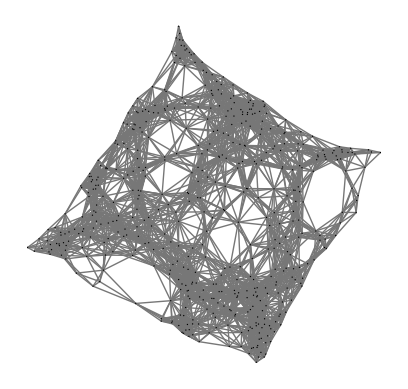

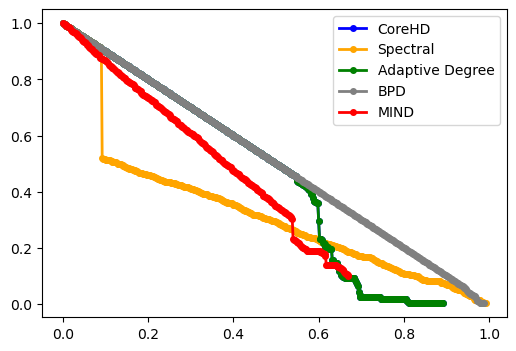

{}

In [ ]:
# Setup SBM
# Generate a 2D Random Geometric Graph
# n=500 nodes, radius=0.12 (threshold for connectivity)
G_rgg = ig.Graph.GRG(n=500, radius=0.12)
G_rgg.vs['static_id'] =list(range(G_rgg.vcount())) 
plot_graph(G_rgg)
benchmark_dismantling(G_rgg, methods)